# 강원특별자치도_가축사육업.csv

In [10]:
import pandas as pd

data = pd.read_csv('./data_csv/강원특별자치도_가축사육업.csv', encoding='cp949')

# 1. 컬럼 조사

In [11]:
import pandas as pd

df = pd.read_csv('./data_csv/강원특별자치도_가축사육업.csv', encoding='cp949')

cols = pd.DataFrame({
    "index": range(len(df.columns)),
    "column_name": df.columns
})

cols

,index,column_name
0,0,번호
1,1,개방서비스명
2,2,개방서비스아이디
3,3,개방자치단체코드
4,4,관리번호
5,5,인허가일자
6,6,인허가취소일자
7,7,영업상태구분코드
8,8,영업상태명
9,9,상세영업상태코드


In [12]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv('./data_csv/강원특별자치도_가축사육업.csv', encoding='cp949')

# 인허가일자 문자열을 날짜로 변환
df['인허가일자'] = pd.to_datetime(df['인허가일자'], errors='coerce')

# 연도 추출
df['permit_year'] = df['인허가일자'].dt.year

# 폐업 여부 판단 → 영업상태명 사용
df['is_closed'] = df['영업상태명'] == '폐업'

# 연도별 총 업체 수
total_by_year = df.groupby('permit_year')['번호'].count()

# 연도별 폐업 수
closed_by_year = df.groupby('permit_year')['is_closed'].sum()

# 결과 합치기
result = pd.DataFrame({
    '총업체수': total_by_year,
    '폐업수': closed_by_year
})

# 폐업률 계산
result['폐업률(%)'] = (result['폐업수'] / result['총업체수'] * 100).round(2)

result

,총업체수,폐업수,폐업률(%)
permit_year,,,
2004,675,220,32.59
2005,2428,837,34.47
2006,315,59,18.73
2007,683,235,34.41
2008,2067,1065,51.52
2009,601,294,48.92
2010,278,110,39.57
2011,404,183,45.30
2012,336,123,36.61


In [13]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 계패업 비율 조사 하여 해당 연도까지의 위험 업종인지를 판단함. 

In [20]:
data_columns = data.columns[data.isnull().all()]
data_columns
data.drop(columns = data_columns, inplace = True)

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14891 entries, 0 to 14890
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   번호               14891 non-null  int64  
 1   개방서비스명           14891 non-null  object 
 2   개방서비스아이디         14891 non-null  object 
 3   개방자치단체코드         14891 non-null  int64  
 4   관리번호             14891 non-null  int64  
 5   인허가일자            14891 non-null  object 
 6   영업상태구분코드         14891 non-null  int64  
 7   영업상태명            14891 non-null  object 
 8   상세영업상태코드         14891 non-null  int64  
 9   상세영업상태명          14891 non-null  object 
 10  폐업일자             6041 non-null   object 
 11  휴업시작일자           416 non-null    object 
 12  휴업종료일자           413 non-null    object 
 13  재개업일자            90 non-null     object 
 14  소재지전화            2797 non-null   object 
 15  소재지면적            7224 non-null   float64
 16  소재지우편번호          11386 non-null  object 
 17  소재지전체주소     

In [26]:
import numpy as np
total_size = data['폐업일자'].size
total_size
def make_autopct_with_count(pct):
    absolute_count = int(np.round(pct*total_size/100))
    return f"{pct:.1f}%\n({absolute_count}명)"

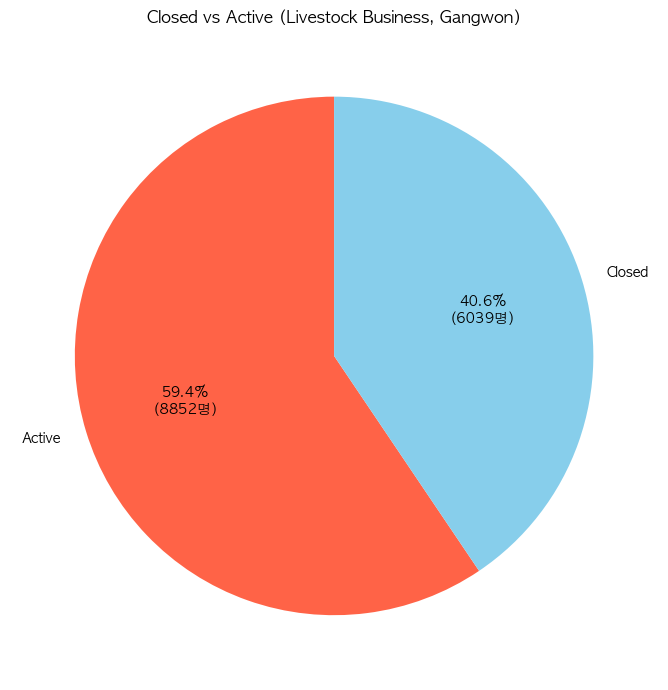

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/Users/mac/Desktop/project/company_data/second_week/data_csv/강원특별자치도_가축사육업.csv', encoding='cp949')

# 폐업 여부 분류
df['Status'] = df['영업상태명'].apply(lambda x: 'Closed' if x == '폐업' else 'Active')

status_counts = df['Status'].value_counts()

# 파이차트
plt.figure(figsize=(7,7))
plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct=make_autopct_with_count,
    startangle=90,
    colors=['tomato','skyblue']
)
plt.title('Closed vs Active (Livestock Business, Gangwon)')
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os

read_dir = os.path.join(os.getcwd(),'data_csv','강원특별자치도_가축사육업.csv')
read_dir
df = pd.read_csv(read_dir,encoding = 'cp949')

# 5년 폐업률을 통해 올해의 폐업 위험률을 조사

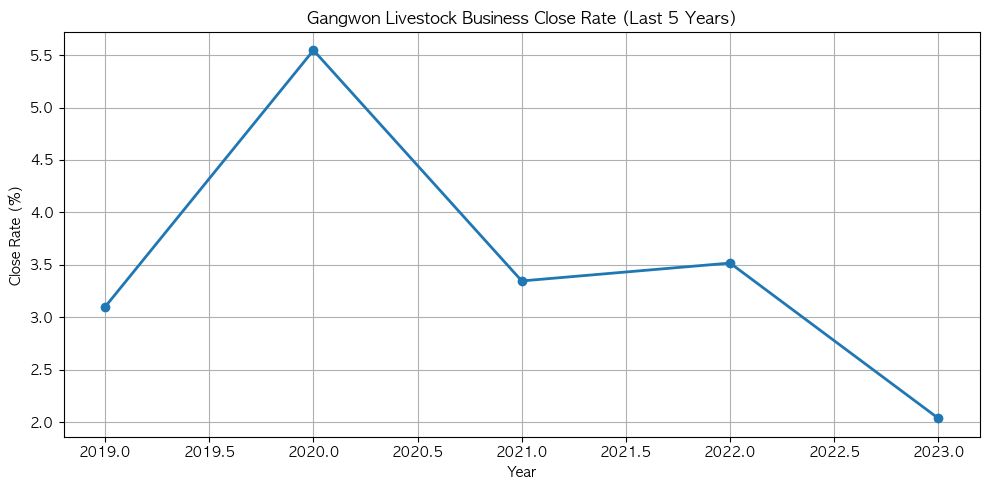

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/Users/mac/Desktop/project/company_data/second_week/data_csv/강원특별자치도_가축사육업.csv',
                 encoding='cp949')

# 날짜 처리
df['인허가일자'] = pd.to_datetime(df['인허가일자'], errors='coerce')
df['폐업일자'] = pd.to_datetime(df['폐업일자'], errors='coerce')

# 최근 5개년
years = list(range(2019, 2024))

result = []

for year in years:
    # 해당 연도까지 존재하는 전체 업체
    total = df[df['인허가일자'].dt.year <= year].shape[0]

    # 해당 연도에 폐업한 업체
    closed = df[df['폐업일자'].dt.year == year].shape[0]

    rate = (closed / total * 100) if total > 0 else 0

    result.append([year, total, closed, rate])

# DataFrame
result_df = pd.DataFrame(result, columns=['Year', 'Total', 'Closed', 'CloseRate'])

# Plot
plt.figure(figsize=(10,5))
plt.plot(result_df['Year'], result_df['CloseRate'], marker='o', linewidth=2)

plt.title("Gangwon Livestock Business Close Rate (Last 5 Years)")
plt.xlabel("Year")
plt.ylabel("Close Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv('./data_csv/강원특별자치도_가축사육업.csv', encoding='cp949')

# 영업상태명 빈도 테이블
status_table = df['영업상태명'].value_counts().reset_index()
status_table.columns = ['영업상태명', 'Count']

status_table

,영업상태명,Count
0,영업/정상,7326
1,폐업,6039
2,취소/말소/만료/정지/중지,1118
3,휴업,408


     주사육업종  total_business  closed_business  close_rate
11      오리              31               25   80.645161
4       돼지             634              371   58.517350
9       산양             197              115   58.375635
12      육계             494              252   51.012146
0       거위               2                1   50.000000
16     칠면조               2                1   50.000000
15  종계/산란계             318              148   46.540881
3        꿩               9                4   44.444444
7       사슴              99               40   40.404040
6       면양              20                8   40.000000
18      한우           12177             4839   39.738852
13      육우              67               26   38.805970
17      타조               7                2   28.571429
14      젖소             363              103   28.374656
10      염소             398              101   25.376884
5      메추리               6                1   16.666667
2       꿀벌              64                2    3

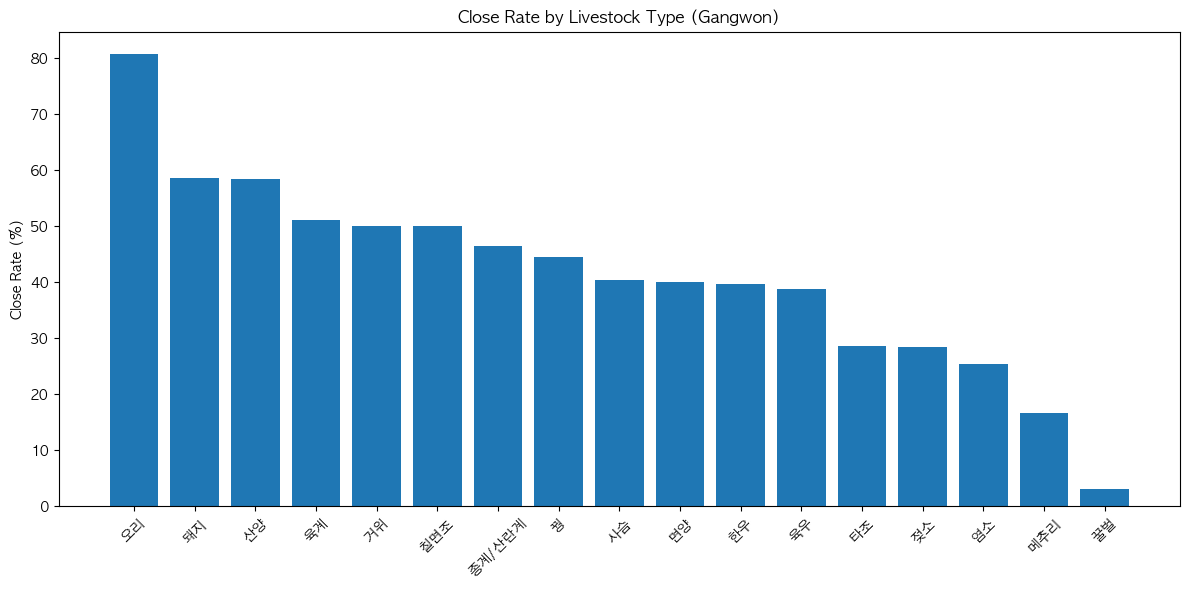

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/Users/mac/Desktop/project/company_data/second_week/data_csv/강원특별자치도_가축사육업.csv',
                 encoding='cp949')

# 날짜 변환
df['인허가일자'] = pd.to_datetime(df['인허가일자'], errors='coerce')
df['폐업일자'] = pd.to_datetime(df['폐업일자'], errors='coerce')

# 주사육업종 비어 있으면 Unknown 처리
df['주사육업종'] = df['주사육업종'].fillna('Unknown')

# 폐업 여부 플래그
df['is_closed'] = df['영업상태명'].apply(lambda x: 1 if x == '폐업' else 0)

# 🔥 먼저 remove_list 정의
remove_list = ['산림육성계', '기러기', '산란육성계']

# 그룹화 (전체 수 , 폐업 수)
group = df.groupby('주사육업종').agg(
    total_business=('주사육업종', 'count'),
    closed_business=('is_closed', 'sum')
).reset_index()

# 🔥 불필요한 값 제거
group = group[~group['주사육업종'].isin(remove_list)]

# 폐업률 계산
group['close_rate'] = group['closed_business'] / group['total_business'] * 100

# 정렬
group = group.sort_values('close_rate', ascending=False)

print(group)

# 그래프
plt.figure(figsize=(12,6))
plt.bar(group['주사육업종'], group['close_rate'])
plt.xticks(rotation=45)
plt.ylabel("Close Rate (%)")
plt.title("Close Rate by Livestock Type (Gangwon)")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Load data
df = pd.read_csv('/Users/mac/Desktop/project/company_data/second_week/data_csv/강원특별자치도_가축사육업.csv',
                 encoding='cp949')

# 폐업 여부 확인
df['is_closed'] = df['영업상태명'].apply(lambda x: 1 if x == '폐업' else 0)

# 주사육업종 NaN 제거
df2 = df.dropna(subset=['주사육업종']).copy()

# 주사육업종별 폐업률 계산
group = df2.groupby('주사육업종')['is_closed'].mean().reset_index()
group['CloseRate(%)'] = (group['is_closed'] * 100).round(1)

# 불필요한 값(결측치) 제거
remove_list = ['산림육성계', '기러기','산란육성계']
group = group[~group['주사육업종'].isin(remove_list)]

# is_closed 컬럼 제거 후 정렬
group = group[['주사육업종', 'CloseRate(%)']].sort_values('CloseRate(%)', ascending=False).reset_index(drop=True)

group

,주사육업종,CloseRate(%)
0,오리,80.6
1,돼지,58.5
2,산양,58.4
3,육계,51.0
4,거위,50.0
5,칠면조,50.0
6,종계/산란계,46.5
7,꿩,44.4
8,사슴,40.4
9,면양,40.0
